In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set Seaborn aesthetic theme
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_amazon_sales.csv')

# Dataset overview and basic statistics
print("Dataset Shape:", df.shape)

print("\n--- Summary Statistics ---")
print(df[['discounted_price_clean', 'actual_price_clean', 'discount_percentage_clean', 'rating_clean', 'rating_count_clean']].describe())

print("\n--- Column Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Category Breakdown ---")
print(df['main_category'].value_counts())

Dataset Shape: (1465, 22)

--- Summary Statistics ---
       discounted_price_clean  actual_price_clean  discount_percentage_clean  \
count             1465.000000         1465.000000                1465.000000   
mean              3125.310874         5444.990635                  47.691468   
std               6944.304394        10874.826864                  21.635905   
min                 39.000000           39.000000                   0.000000   
25%                325.000000          800.000000                  32.000000   
50%                799.000000         1650.000000                  50.000000   
75%               1999.000000         4295.000000                  63.000000   
max              77990.000000       139900.000000                  94.000000   

       rating_clean  rating_count_clean  
count   1464.000000         1463.000000  
mean       4.096585        18295.541353  
std        0.291674        42753.864952  
min        2.000000            2.000000  
25%        4.00

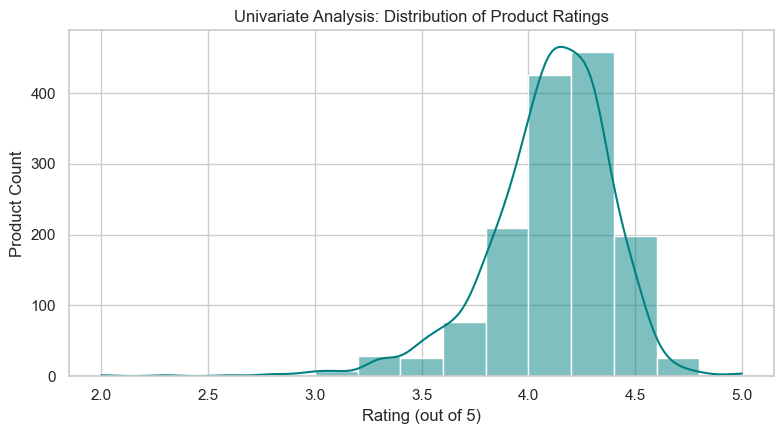

In [4]:
# Plot rating distribution histogram and KDE curve
plt.figure(figsize=(8, 4.5))
sns.histplot(df['rating_clean'].dropna(), bins=15, kde=True, color='teal')
plt.title('Univariate Analysis: Distribution of Product Ratings')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Product Count')
plt.tight_layout()
plt.savefig('1_rating_distribution.png', dpi=300)
plt.show()

Observation: Ratings are left-skewed, peaking sharply between 4.0 and 4.3. Very few products fall below 3.5, indicating generally positive customer feedback across Amazon listings.

C:\Users\ZhuanZ1\AppData\Local\Temp\ipykernel_7152\1322864253.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['main_category'].isin(top_cats)], x='main_category', y='discounted_price_clean', palette='Set2')


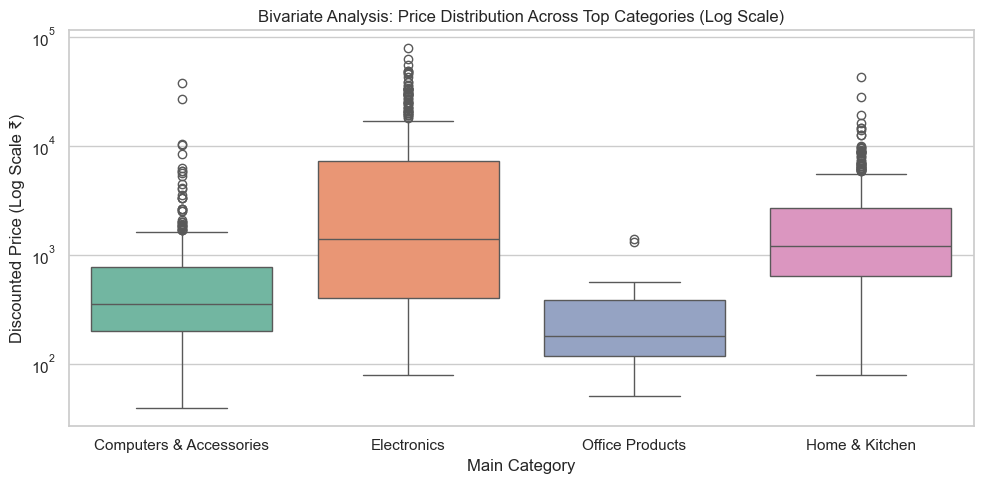

In [5]:
# Plot price distribution across major categories on a log scale
plt.figure(figsize=(10, 5))
top_cats = df['main_category'].value_counts().head(4).index
sns.boxplot(data=df[df['main_category'].isin(top_cats)], x='main_category', y='discounted_price_clean', palette='Set2')
plt.yscale('log')
plt.title('Bivariate Analysis: Price Distribution Across Top Categories (Log Scale)')
plt.xlabel('Main Category')
plt.ylabel('Discounted Price (Log Scale ₹)')
plt.tight_layout()
plt.savefig('2_price_boxplot_category.png', dpi=300)
plt.show()

Observation: Electronics exhibits the widest interquartile price range and numerous high-end outliers (e.g., premium smart TVs). Office Products has the lowest median price and minimal variation.

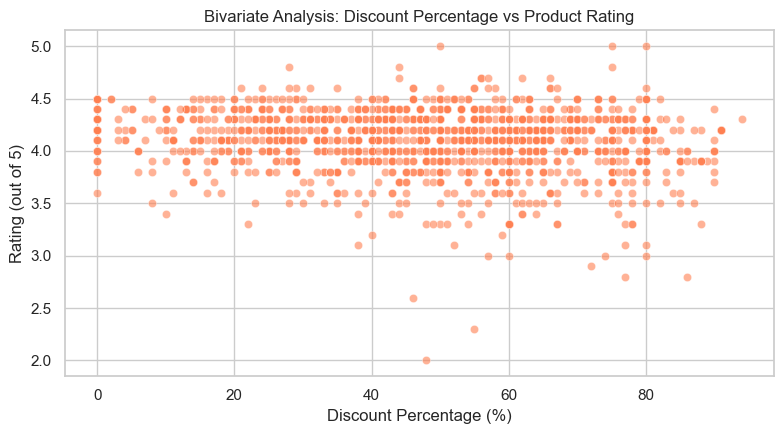

In [6]:
# Plot relationship between discount percentage and ratings
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df, x='discount_percentage_clean', y='rating_clean', alpha=0.6, color='coral')
plt.title('Bivariate Analysis: Discount Percentage vs Product Rating')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Rating (out of 5)')
plt.tight_layout()
plt.savefig('3_discount_vs_rating.png', dpi=300)
plt.show()

Observation: Product ratings remain evenly scattered across all discount ranges ($0\%$ to $90\%$). Massive discounts do not systematically drive higher or lower customer satisfaction scores.

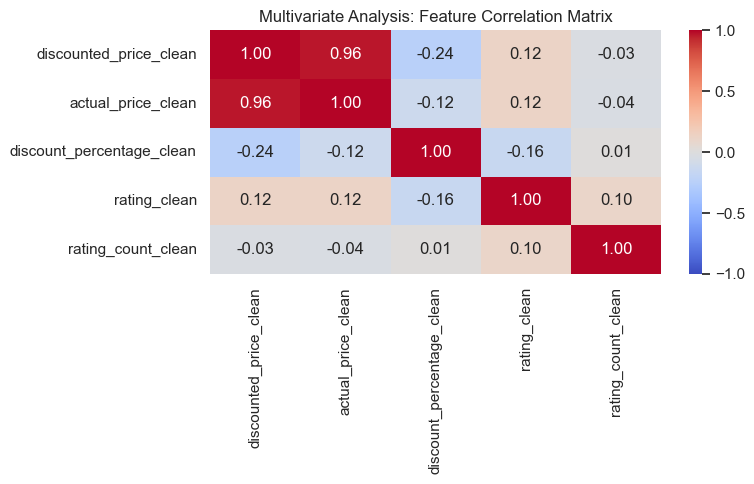

In [7]:
# Correlation matrix heatmap for numerical variables
plt.figure(figsize=(8, 5))
numeric_cols = ['discounted_price_clean', 'actual_price_clean', 'discount_percentage_clean', 'rating_clean', 'rating_count_clean']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Multivariate Analysis: Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('4_correlation_heatmap.png', dpi=300)
plt.show()

Observation: discounted_price_clean and actual_price_clean exhibit a near-perfect positive correlation ($r = 0.96$). discount_percentage_clean shows a weak negative correlation with product rating ($r = -0.16$).

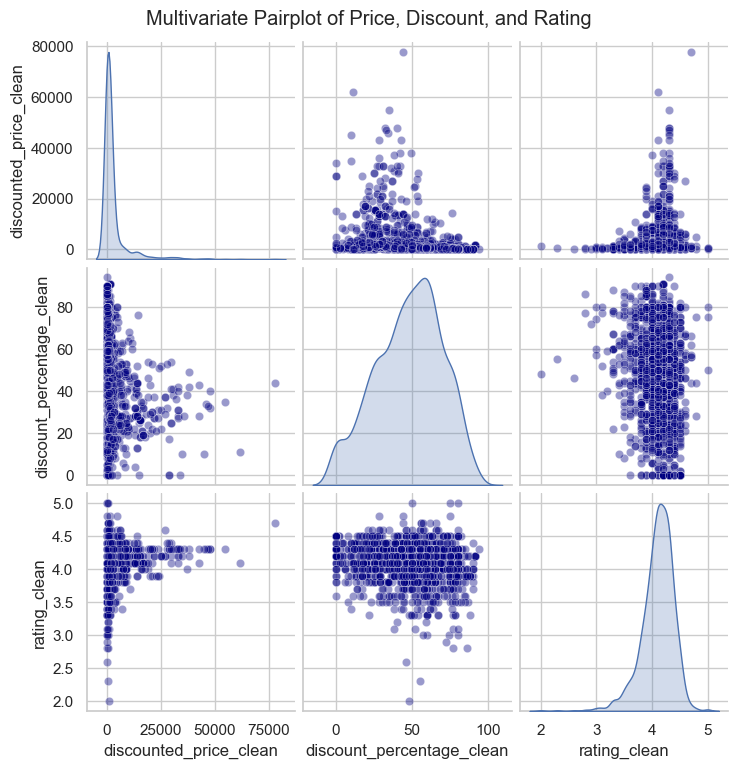

In [8]:
# Pairplot for numerical interactions
pair_df = df[['discounted_price_clean', 'discount_percentage_clean', 'rating_clean']].dropna()
pair_plot = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.4, 'color': 'navy'})
pair_plot.fig.suptitle('Multivariate Pairplot of Price, Discount, and Rating', y=1.02)
pair_plot.savefig('5_pairplot.png', dpi=300)
plt.show()

Observation: KDE diagonal plots highlight heavy right-skewness in price fields and left-skewness in ratings. Bivariate scatter plots show uniform customer feedback density across price bands.

## Task 5 Interview Questions & Answers

1. **Which plots do you use to check correlation?**
   - Heatmaps (`sns.heatmap()`) for correlation matrices and Scatter plots (`sns.scatterplot()`) or Pairplots (`sns.pairplot()`).

2. **How do you handle skewed data?**
   - Apply Log Transformations (`np.log1p`), Box-Cox/Yeo-Johnson transformations, or use non-parametric summary metrics (Median and IQR instead of Mean and Std).

3. **How to detect multicollinearity?**
   - Calculate Variance Inflation Factor (VIF > 5 or 10) or inspect heatmaps for feature pairs with correlation coefficients |r| > 0.8.

4. **What are univariate, bivariate, and multivariate analyses?**
   - **Univariate:** Analyzing a single variable in isolation (e.g., rating histogram).
   - **Bivariate:** Analyzing relationships between two variables (e.g., discount % vs. rating).
   - **Multivariate:** Examining interactions among three or more variables simultaneously (e.g., pairplots or correlation heatmaps).

5. **Difference between heatmap and pairplot?**
   - A **heatmap** displays single aggregated metrics (like correlation coefficients) as a colored 2D grid matrix. A **pairplot** displays actual grid matrices of scatter plots and distribution curves for all numerical feature pairs.

6. **How do you summarize your insights?**
   - Highlight core business takeaways and statistical findings clearly, pairing data figures directly with visual evidence.

7. **What is EDA and why is it important?**
   - Exploratory Data Analysis is the critical initial process of analyzing datasets to discover patterns, spot anomalies, test hypotheses, and check assumptions using summary statistics and visualizations before model building.